In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class SliceDataset(Dataset):
    def __init__(self, folder):
        self.folder = folder
        
        self.ct_files = sorted([f for f in os.listdir(folder) if "ct" in f])
        self.mask_files = sorted([f for f in os.listdir(folder) if "mask" in f])

    def __len__(self):
        return len(self.ct_files)

    def __getitem__(self, idx):
        ct = np.load(os.path.join(self.folder, self.ct_files[idx]))
        mask = np.load(os.path.join(self.folder, self.mask_files[idx]))

        # normalize CT
        ct = (ct - ct.min()) / (ct.max() - ct.min() + 1e-8)

        # convert to tensor
        ct = torch.tensor(ct, dtype=torch.float32).unsqueeze(0)   # [1, H, W]
        mask = torch.tensor(mask, dtype=torch.float32)            # [5, H, W]

        # 🔥 resize FIX
        ct = F.interpolate(ct.unsqueeze(0), size=(256,256), mode='bilinear', align_corners=False).squeeze(0)
        mask = F.interpolate(mask.unsqueeze(0), size=(256,256), mode='nearest').squeeze(0)

        return ct, mask

In [4]:
dataset = SliceDataset("slices")
loader = DataLoader(dataset, batch_size=4, shuffle=True)

print("Total samples:", len(dataset))

Total samples: 10832


In [5]:
ct, mask = next(iter(loader))

print("CT shape:", ct.shape)
print("Mask shape:", mask.shape)

CT shape: torch.Size([4, 1, 256, 256])
Mask shape: torch.Size([4, 5, 256, 256])


In [6]:
class SimpleUNet(nn.Module):
    def __init__(self):
        super(SimpleUNet, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 5, 3, padding=1)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x

In [7]:
model = SimpleUNet().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [8]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [9]:
epochs = 2

for epoch in range(epochs):
    model.train()
    total_loss = 0

    print(f"\nEpoch {epoch+1}")

    for i, (ct, mask) in enumerate(loader):
        ct = ct.to(device)
        mask = mask.to(device)

        output = model(ct)
        loss = criterion(output, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if i % 50 == 0:
            print(f"Batch {i}, Loss: {loss.item():.4f}")

    print(f"Epoch Loss: {total_loss:.4f}")


Epoch 1
Batch 0, Loss: 0.7230
Batch 50, Loss: 0.0630
Batch 100, Loss: 0.0659
Batch 150, Loss: 0.0589
Batch 200, Loss: 0.0517
Batch 250, Loss: 0.0548
Batch 300, Loss: 0.0292
Batch 350, Loss: 0.0657
Batch 400, Loss: 0.0503
Batch 450, Loss: 0.0637
Batch 500, Loss: 0.0606
Batch 550, Loss: 0.0312
Batch 600, Loss: 0.0643
Batch 650, Loss: 0.0636
Batch 700, Loss: 0.0459
Batch 750, Loss: 0.0351
Batch 800, Loss: 0.0639
Batch 850, Loss: 0.0602
Batch 900, Loss: 0.0461
Batch 950, Loss: 0.0452
Batch 1000, Loss: 0.0536
Batch 1050, Loss: 0.0254
Batch 1100, Loss: 0.0606
Batch 1150, Loss: 0.0409
Batch 1200, Loss: 0.0544
Batch 1250, Loss: 0.0730
Batch 1300, Loss: 0.0268
Batch 1350, Loss: 0.0333
Batch 1400, Loss: 0.0400
Batch 1450, Loss: 0.0251
Batch 1500, Loss: 0.0377
Batch 1550, Loss: 0.0478
Batch 1600, Loss: 0.0241
Batch 1650, Loss: 0.0235
Batch 1700, Loss: 0.0498
Batch 1750, Loss: 0.0462
Batch 1800, Loss: 0.0558
Batch 1850, Loss: 0.0711
Batch 1900, Loss: 0.0572
Batch 1950, Loss: 0.0618
Batch 2000, Lo

In [11]:
!ls

DataPreprocessed.ipynb	model_epoch2_new.pth  slices	  training.ipynb
model_checkpoint.pth	README.md	      slices.zip


In [16]:
torch.save(model.state_dict(), "model_epoch2_new.pth")
print("New model saved!")

New model saved!


In [9]:
model = SimpleUNet().to(device)
model.load_state_dict(torch.load("model_epoch2_new.pth"))
model.eval()

/tmp/ipykernel_137/2072937896.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_epoch2_new.pth"))


SimpleUNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 5, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
)

In [17]:
def dice_score(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    dice = 0

    for c in range(pred.shape[1]):   # 5 channels
        p = pred[:, c].contiguous().view(-1)
        t = target[:, c].contiguous().view(-1)

        intersection = (p * t).sum()
        union = p.sum() + t.sum()

        dice += (2 * intersection + eps) / (union + eps)

    return dice / pred.shape[1]

In [18]:
ct, mask = next(iter(loader))

ct = ct.to(device)
mask = mask.to(device)

with torch.no_grad():
    output = model(ct)
    dice = dice_score(output, mask)

print("Correct Dice Score:", dice.item())

Correct Dice Score: 0.00034416417474858463


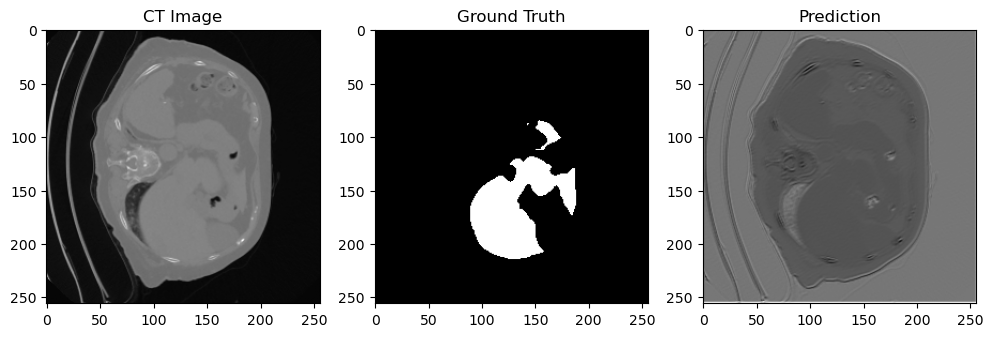

In [20]:
import matplotlib.pyplot as plt

# Take one batch
ct, mask = next(iter(loader))

# Move to device
ct = ct.to(device)
mask = mask.to(device)

# Get prediction
with torch.no_grad():
    output = model(ct)

# Convert everything to CPU + numpy
ct_np = ct[0][0].cpu().numpy()                 # [H, W]
mask_np = mask[0][0].cpu().numpy()             # first channel
pred_np = torch.sigmoid(output)[0][0].cpu().numpy()

# Plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(ct_np, cmap='gray')
plt.title("CT Image")

plt.subplot(1,3,2)
plt.imshow(mask_np, cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_np, cmap='gray')
plt.title("Prediction")

plt.show()

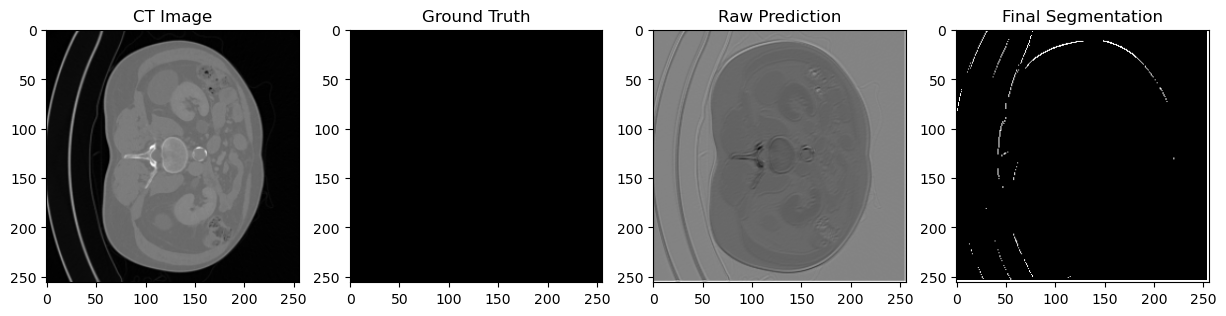

In [21]:
import matplotlib.pyplot as plt

# Get one batch
ct, mask = next(iter(loader))

# Move to device
ct = ct.to(device)
mask = mask.to(device)

# Get prediction
with torch.no_grad():
    output = model(ct)

# Convert to numpy
ct_np = ct[0][0].cpu().numpy()
mask_np = mask[0][0].cpu().numpy()

# Raw prediction
pred_prob = torch.sigmoid(output)[0][0].cpu().numpy()

# Thresholded prediction (IMPORTANT)
pred_bin = (pred_prob > 0.5).astype(float)

# Plot everything
plt.figure(figsize=(15,4))

# CT
plt.subplot(1,4,1)
plt.imshow(ct_np, cmap='gray')
plt.title("CT Image")

# Ground truth
plt.subplot(1,4,2)
plt.imshow(mask_np, cmap='gray')
plt.title("Ground Truth")

# Raw prediction
plt.subplot(1,4,3)
plt.imshow(pred_prob, cmap='gray')
plt.title("Raw Prediction")

# Final segmentation
plt.subplot(1,4,4)
plt.imshow(pred_bin, cmap='gray')
plt.title("Final Segmentation")

plt.show()